# ASL Detection using Deep Learning
American Sign Language (ASL) is a visual language used by the deaf and hard-of-hearing community to communicate through hand gestures representing alphabets, words, and sentences.

In this project, I have developed a real-time ASL alphabet detection system using deep learning and computer vision techniques. The model takes hand gesture images as input and predicts the corresponding alphabet (A-Z) along with special symbols like SPACE, DELETE, and NOTHING.

To achieve high accuracy and efficiency, I have used Transfer Learning with MobileNetV2, a pretrained convolutional neural network that extracts meaningful visual features from images. The system is further integrated with OpenCV to perform real-time predictions using a webcam.


## Objectives
Classify ASL hand gestures into 29 classes

Build a high-accuracy deep learning model

Perform real-time prediction using webcam

Create a system useful for assistive communication



##### To Run This Project

1. Download dataset from Kaggle:  
 [ASL Alphabet Dataset](https://www.kaggle.com/datasets/grassknoted/asl-alphabet/data)

2. Upload it to Google Drive  

3. Update dataset path in the notebook

In [2]:
!pip install tensorflow opencv-python matplotlib

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
print("GPU:", tf.config.list_physical_devices('GPU'))
import matplotlib.pyplot as plt
import numpy as np
import os


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1. Mount Google Drive
Connect Google Drive to Colab:

It allows access to dataset stored in drive and is useful for saving trained model.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Data Preprocessing
Define image size (required by MobileNetV2)

Batch size = number of images processed at once

Normalize pixel values (0–255 → 0–1)

Split data:
80% training
20% validation

Load images from dataset folders

Automatically assigns labels based on folder names

Creates training & validation datasets.

train_dir → tells model where training images are

test_dir → test images

flow_from_directory() → automatically reads:
folders (A, B, C…)
assigns labels

In [5]:
IMG_SIZE = 160
BATCH_SIZE = 16


train_dir = "/content/drive/MyDrive/asl_dataset/asl_detection/asl_alphabet_train"
test_dir  = "/content/drive/MyDrive/asl_dataset/asl_detection/asl_alphabet_test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 69788 images belonging to 1 classes.
Found 17447 images belonging to 1 classes.


### 3. Load MobileNetV2
Load pretrained model trained on ImageNet

include_top = False → used to remove original classification layer

Keeps feature extraction layers

In [6]:
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze pretrained layers

Prevents retraining → saves time & improves stability

In [7]:
base_model.trainable = False

### 4. Build Model
Add custom layers on top:

GlobalAveragePooling → reduces dimensions

Dense (ReLU) → learns patterns

Dropout → prevents overfitting

Softmax → outputs probabilities for 29 classes


In [8]:
num_classes = train_generator.num_classes
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

###5. Compile Model
Configure model training:

Adam → optimizer

Categorical Crossentropy → for multi-class classification

Accuracy → evaluation metric

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 6. Train Model
Train the model on dataset

Learns patterns of hand gestures

Stores training history (accuracy, loss)

In [11]:
EPOCHS = 5

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    steps_per_epoch=200,
    validation_steps=50
)

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1363s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1220s 6s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1142s 6s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1088s 5s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 1027s 5s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


### 7. Plot Accuracy
Visualizes:

Training accuracy

Validation accuracy

Helps detect overfitting

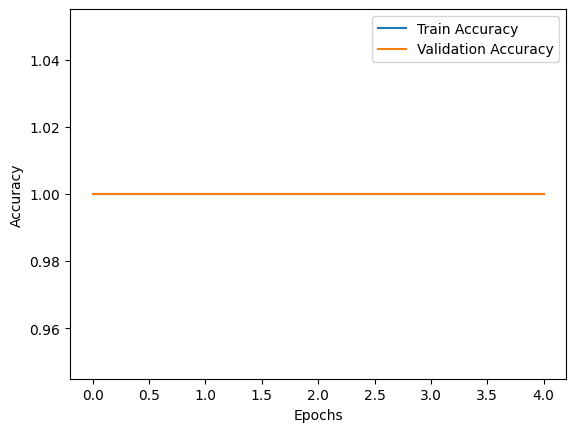

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 8. Save Model
Saves trained model

Can be reused without retraining

In [27]:
model.save('/content/asl_model.h5')

In [28]:
import os
print(os.listdir('/content'))

['.config', 'asl_model_mobilenetv2.h5', 'asl_model.h5', 'drive', 'sample_data']


### 9. Download Model

In [25]:
from google.colab import files
files.download('/content/asl_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion
The model was successfully trained using MobileNetV2 for ASL classification. To optimize training time and computational resources, reduced epochs and steps were used, achieving high accuracy while maintaining efficiency. The trained model was saved for real-time deployment.